In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots
from spectral_lines import LINES, print_available_lines

In [3]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

In [4]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [5]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [6]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


#  Data Ha

In [7]:
cfg = LINES["Halpha"]

plot_label_line      = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element         = cfg.element
ion             = cfg.ion
transition_id   = cfg.transition_id

In [8]:
print(plot_label_line)
print(rest_wavelength)
print(wavelength_id)
print(element)
print(ion)
print(transition_id)

H$\alpha$
6562.79
6563
H
Ha
H_I-6563


In [9]:
#line        = r'H$\alpha$'
#lambda_rest = 6562.8
#line_id     = 'H'
#line_id2   = "6563"

In [10]:


#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + str(wavelength_id)
name_id      =  inst_id + '-' + reg_id + '-' + element + "-X"
print(name_file)
print(name_id)


LVM-30Dor-6563
LVM-30Dor-H-X


In [11]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [12]:
centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)


In [13]:


radio = 3305 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


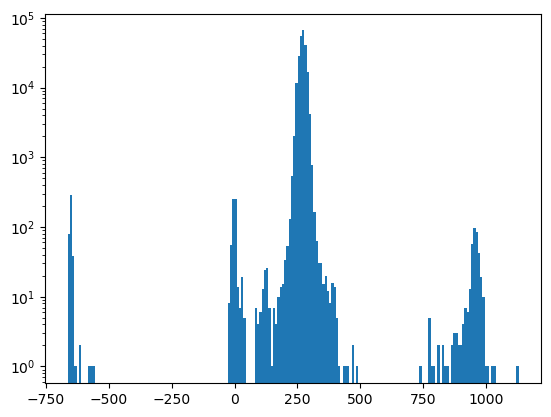

In [14]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [15]:
mask = (line_rad["V_mean"] > 220) & (line_rad["V_mean"]<330) & (line_rad["log_F"] > 100)  & (line_rad["sigma"] < 1.5) 
line_mask = line_rad[mask]

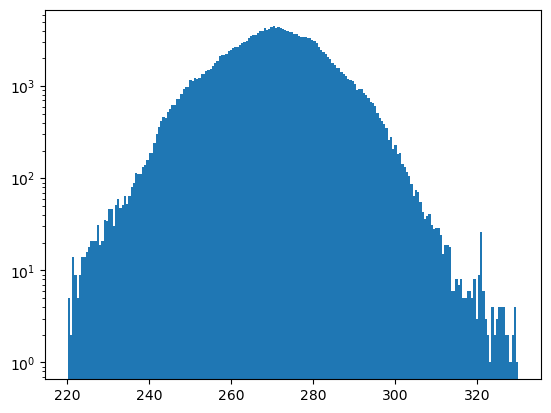

In [16]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"][mask] , bins=200)
ax.set_yscale("log")

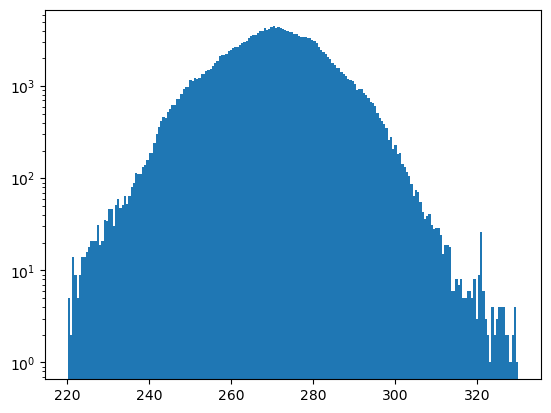

In [17]:
fig, ax = plt.subplots()
plt.hist(line_mask["V_mean"] , bins=200)
ax.set_yscale("log")

Plot flux and radial velocity

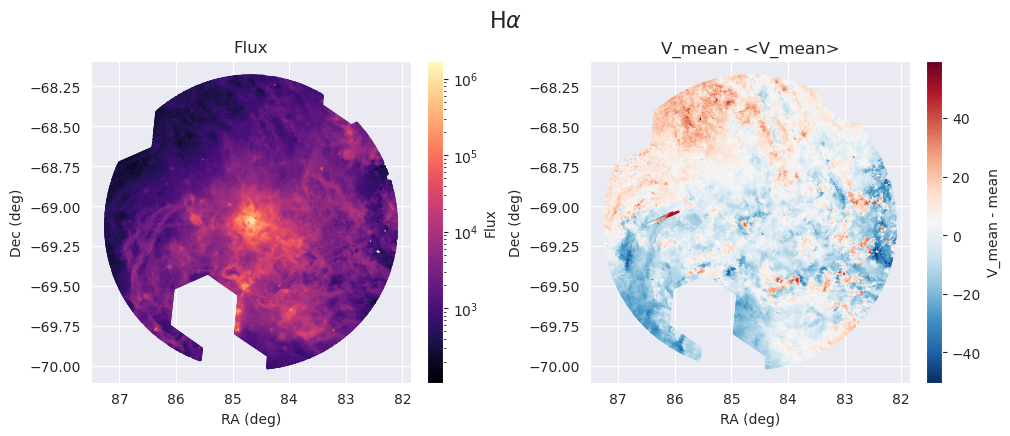

In [18]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=plot_label_line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

Plot flux and radial velocity in WCS

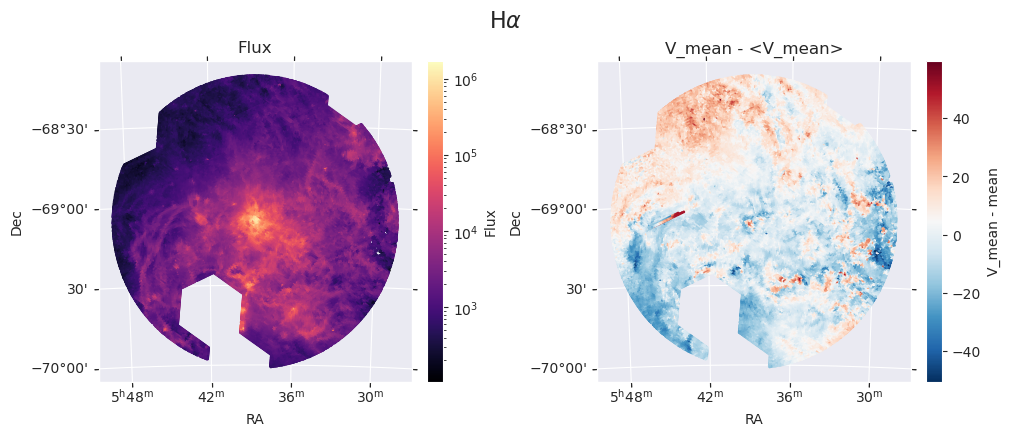

In [19]:
fig, ax = list_maps_plots.plot_panels_wcs(line_mask,
                                          wcs,
                                          s=1.0,
                                          figsize=(10, 4.25),
                                          invert_ra=False, 
                                          titles=("Flux", "V_mean - <V_mean>"),
                                          figure_title=plot_label_line)
plt.show()

#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

In [20]:
df_Ha = line_mask.copy()

In [21]:
df_Ha.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,222020.000000,222020.000000,222020.000000,2.220200e+05,222020.000000
mean,84.743434,-69.080949,270.401268,9.276494e+03,0.841440
std,1.275231,0.427281,12.448334,3.407694e+04,0.129093
min,82.101852,-70.012179,220.023700,1.059342e+02,0.237300
25%,83.781267,-69.404202,262.501525,1.006186e+03,0.752300
50%,84.708755,-69.094773,270.608900,2.636627e+03,0.811500
75%,85.798398,-68.761121,278.533000,6.775874e+03,0.893100
max,87.248872,-68.182110,329.997900,1.710726e+06,1.499700


## Rotation substraction

# Data H$\beta$

In [22]:
cfg = LINES["Hbeta"]

plot_label_line      = cfg.plot_label
rest_wavelength = cfg.rest_wavelength
wavelength_id    = cfg.wavelength_id
element         = cfg.element
ion             = cfg.ion
transition_id   = cfg.transition_id

In [23]:
#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + str(wavelength_id)
name_id      =  inst_id + '-' + reg_id + '-' + element + "-X"
print(name_file)
print(name_id)


LVM-30Dor-4861
LVM-30Dor-H-X


In [24]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [25]:
radio = 3305 * u.arcsec   
sep = coords.separation(centro)

line_rad_O = _line[sep <= radio]

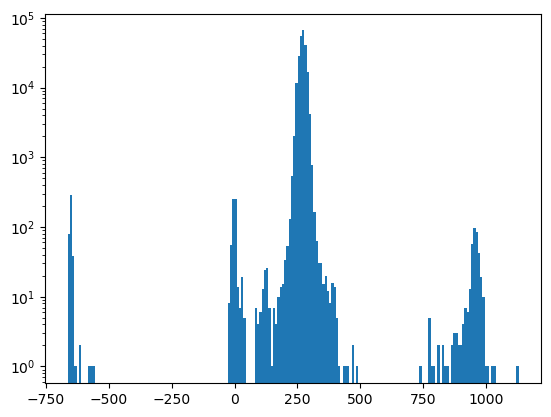

In [26]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [27]:
mask_O = (line_rad_O["V_mean"] > 220) & \
         (line_rad_O["V_mean"]<330) & \
         (line_rad_O["log_F"] > 100)  & (line_rad_O["sigma"] < 1.5) 
line_mask_O = line_rad_O[mask_O].copy()

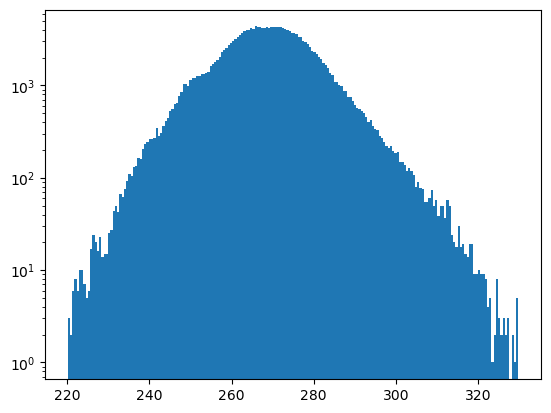

In [28]:
fig, ax = plt.subplots()
plt.hist(line_rad_O["V_mean"][mask_O] , bins=200)
ax.set_yscale("log")

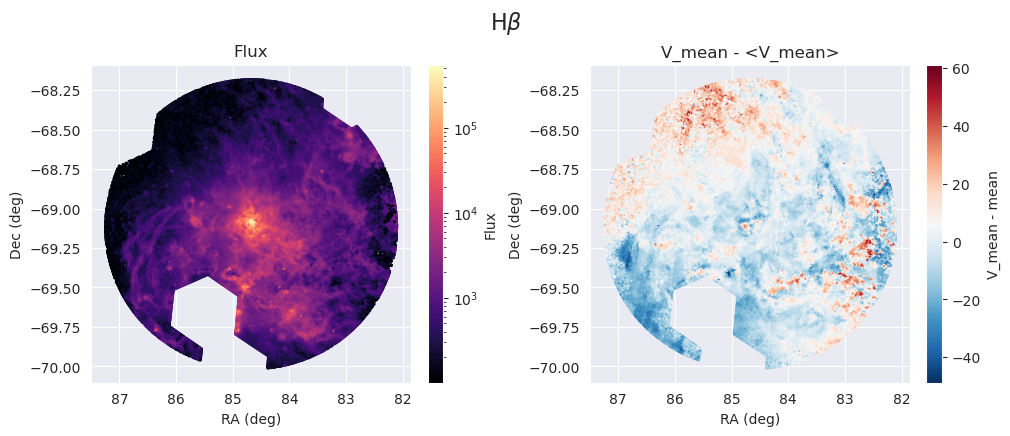

In [29]:
fig, ax = list_maps_plots.plot_panels_log_title(line_mask_O,
                                                s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=plot_label_line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

In [30]:
df_Hb = line_mask_O.copy()

# Line Comparison

In [31]:
line_Ha = line_mask.copy()

In [32]:
line_mask.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,222020.000000,222020.000000,222020.000000,2.220200e+05,222020.000000
mean,84.743434,-69.080949,270.401268,9.276494e+03,0.841440
std,1.275231,0.427281,12.448334,3.407694e+04,0.129093
min,82.101852,-70.012179,220.023700,1.059342e+02,0.237300
25%,83.781267,-69.404202,262.501525,1.006186e+03,0.752300
50%,84.708755,-69.094773,270.608900,2.636627e+03,0.811500
75%,85.798398,-68.761121,278.533000,6.775874e+03,0.893100
max,87.248872,-68.182110,329.997900,1.710726e+06,1.499700


In [33]:
line_rad_O[mask].describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,222020.000000,222020.000000,222020.000000,222020.000000,222020.000000
mean,84.743434,-69.080949,269.209585,2661.091536,0.837987
std,1.275231,0.427281,12.295700,10998.535314,0.119501
min,82.101852,-70.012179,62.108600,-47.266400,0.208300
25%,83.781267,-69.404202,261.760800,316.579250,0.772100
50%,84.708755,-69.094773,269.165850,792.887000,0.813200
75%,85.798398,-68.761121,276.530850,2028.384950,0.871500
max,87.248872,-68.182110,523.678500,549251.003700,2.125000


In [34]:
line_Hb =  line_rad_O[mask].copy()

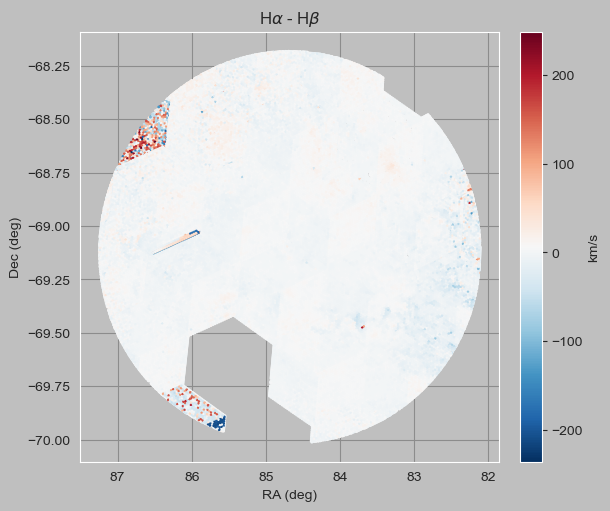

In [35]:
with sns.axes_style(
    "darkgrid",
    rc={
        "axes.facecolor": "0.75",
        "figure.facecolor": "0.75",
        "grid.color": "0.55",
    }
):
    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    dif_vel1 = ax.scatter(line_rad['RAdeg'], line_rad['DEdeg'],
                             s=1.0, 
                             c=line_rad['V_mean']-line_rad_O['V_mean'], 
                             cmap='RdBu_r')
    ax.invert_xaxis()
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(r'H$\alpha$ - H$\beta$')
    fig.colorbar(dif_vel1, ax=ax, label='km/s')
    plt.show()

Text(0.5, 1.0, 'H$\\alpha$ - H$\\beta$')

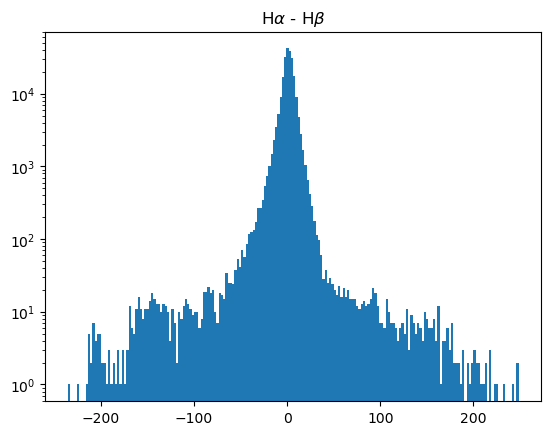

In [36]:
fig, ax = plt.subplots()
plt.hist(line_rad['V_mean']-line_rad_O['V_mean'] , bins=200)
ax.set_yscale("log")
ax.set_title(r'H$\alpha$ - H$\beta$')

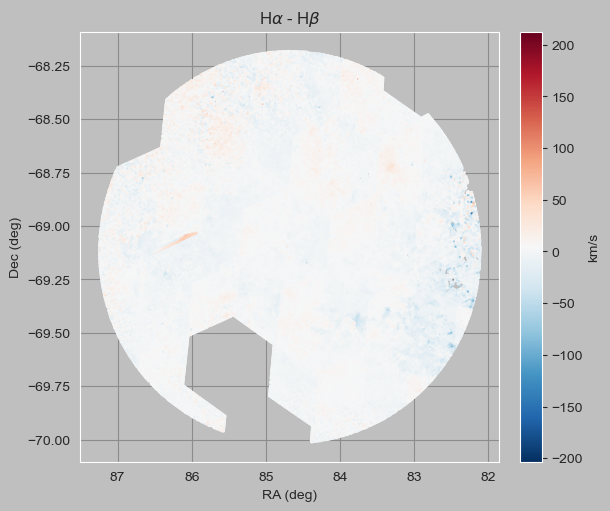

In [37]:
with sns.axes_style(
    "darkgrid",
    rc={
        "axes.facecolor": "0.75",
        "figure.facecolor": "0.75",
        "grid.color": "0.55",
    }
):
    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    dif_vel1 = ax.scatter(line_Ha['RAdeg'], line_Ha['DEdeg'],
                             s=1.0, 
                             c=line_Ha['V_mean']-line_Hb['V_mean'], 
                             cmap='RdBu_r')
    ax.invert_xaxis()
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(r'H$\alpha$ - H$\beta$')
    fig.colorbar(dif_vel1, ax=ax, label='km/s')
    plt.show()

Text(0.5, 1.0, 'H$\\alpha$ - H$\\beta$')

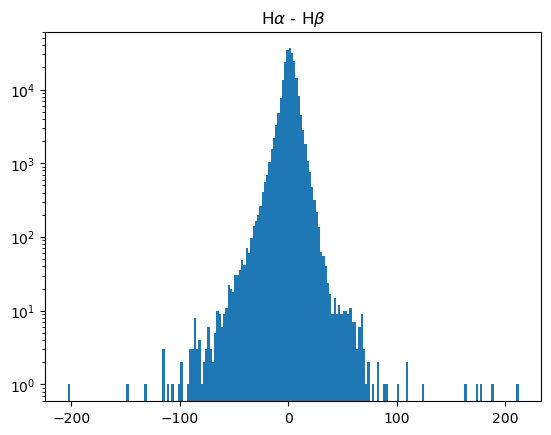

In [38]:
fig, ax = plt.subplots()
plt.hist(line_Ha['V_mean']-line_Hb['V_mean'] , bins=200)
ax.set_yscale("log")
ax.set_title(r'H$\alpha$ - H$\beta$')

# Exctinction

In [39]:
import pyneb as pn

In [40]:
F_Ha = line_Ha['log_F']
F_Hb = line_Hb['log_F']

In [41]:
obs_ratio = F_Ha / F_Hb
obs_ratio.describe()

count    222020.000000
mean          3.625814
std          16.896222
min        -372.531224
25%           3.059747
50%           3.333437
75%           3.628314
max        3939.462514
Name: log_F, dtype: float64

In [42]:
theo_ratio = 2.86

In [43]:
print("fraction below 2.86:", np.mean(obs_ratio < 2.86))

fraction below 2.86: 0.12829925231961084


In [44]:
pn.RedCorr().getLaws()

dict_keys(['No correction', 'CCM89', 'CCM89 Bal07', 'CCM89 oD94', 'S79 H83 CCM89', 'K76', 'SM79 Gal', 'G03 LMC', 'MCC99 FM90 LMC', 'F99-like', 'F99', 'F88 F99 LMC', 'Cal00'])

In [45]:
rc = pn.RedCorr(R_V=3.1, law='CCM89')

In [46]:
rc.setCorr(obs_ratio / theo_ratio, 6563., 4861.)

In [47]:
print("E(B-V) =", rc.E_BV)
print("c(Hbeta) =", rc.cHbeta)
print("A_V =", rc.AV)

E(B-V) = [-0.12752706 -0.15550634 -0.13609701 ...  0.27086755  0.12444257
 -0.0635191 ]
c(Hbeta) = [-0.18409306 -0.22448284 -0.19646429 ...  0.39101374  0.17964041
 -0.09169368]
A_V = [-0.3953339  -0.48206966 -0.42190072 ...  0.8396894   0.38577198
 -0.19690921]


In [48]:
rc.E_BV

array([-0.12752706, -0.15550634, -0.13609701, ...,  0.27086755,
        0.12444257, -0.0635191 ])

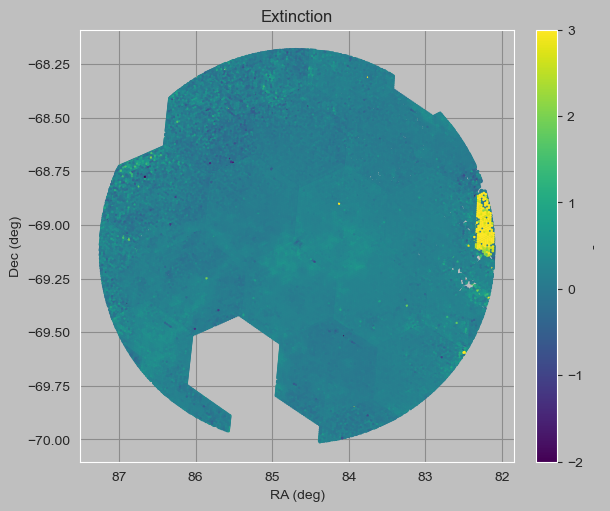

In [49]:
with sns.axes_style(
    "darkgrid",
    rc={
        "axes.facecolor": "0.75",
        "figure.facecolor": "0.75",
        "grid.color": "0.55",
    }
):
    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    dif_vel1 = ax.scatter(line_Ha['RAdeg'], line_Ha['DEdeg'],
                             s=1.0, 
                             c=rc.E_BV, 
                             vmin=-2,
                             vmax=3,
                             cmap='viridis')
    ax.invert_xaxis()
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(r'Extinction')
    fig.colorbar(dif_vel1, ax=ax, label='-')
    plt.show()

In [50]:
df_extinction = pd.DataFrame({
    "obs_ratio": obs_ratio,
    "E_BV": rc.E_BV,
    "Ha_log_F": line_Ha["log_F"].to_numpy(),
    "Hb_log_F": line_Hb["log_F"].to_numpy(),
})

In [51]:
df_extinction["E_BV_negative"] = df_extinction["E_BV"] < 0
df_extinction["E_BV_clipped"] = df_extinction["E_BV"].clip(lower=0)

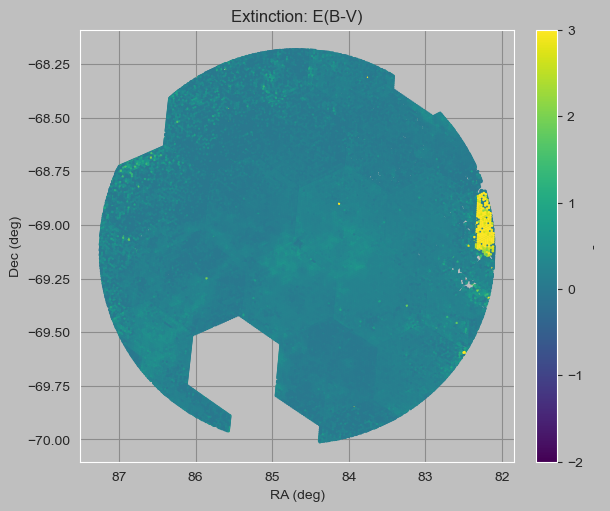

In [54]:
with sns.axes_style(
    "darkgrid",
    rc={
        "axes.facecolor": "0.75",
        "figure.facecolor": "0.75",
        "grid.color": "0.55",
    }
):
    fig, ax = plt.subplots(figsize=(6,5), constrained_layout=True)
    dif_vel1 = ax.scatter(line_Ha['RAdeg'], line_Ha['DEdeg'],
                             s=1.0, 
                             c=df_extinction["E_BV_clipped"], 
                             vmin=-2,
                             vmax=3,
                             cmap='viridis')
    ax.invert_xaxis()
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(r'Extinction: E(B-V)')
    fig.colorbar(dif_vel1, ax=ax, label='-')
    plt.show()

Text(0.5, 1.0, 'E(B-V)')

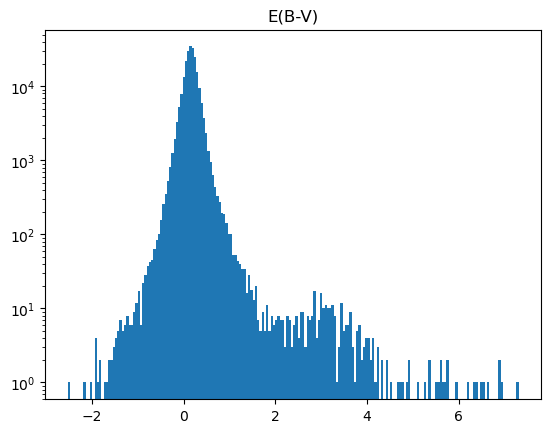

In [53]:
fig, ax = plt.subplots()
plt.hist(rc.E_BV , bins=200)
ax.set_yscale("log")
ax.set_title(r'E(B-V)')